In [1]:
print("Method 2")

Method 2


In [2]:
# how cell-cell interactions change between a subset of immune cells and trophoblast cells 
# as the trophoblast differentiate and invade the maternal uterus

In [3]:
import os
import zipfile

import pandas as pd
import anndata

pd.set_option('display.max_columns', 100)

BASE_DIR = '/home/tanasa/Desktop/CCI_CellPhoneDB'

In [4]:
# --- Input files ---
# cpdb_file_path      : (mandatory) CellphoneDB database zip file. Already downloaded earlier into cellphonedb-data/.
# meta_file_path      : (mandatory) tsv linking cell barcodes to cluster labels.
# counts_file_path    : (mandatory) normalized (log, not z-scaled) counts, h5ad recommended.
# microenvs_file_path : (optional) restricts interactions to cell types within the same microenvironment.
# All four (meta/counts/microenv/DEGs) ship inside CellphoneDB/notebooks/data_tutorial.zip.

In [5]:
# CellPhone will randomly permute the cluster labels of all cells whitin each microenvironement (microenvs_file_path), 
# 1,000 times (default), to test whether the mean average receptor expression level in a cluster and the average ligand expression level 
# between the interacting clusters is higher than those of the rest cell pairs. 

In [6]:
import os
import pandas as pd
import anndata

pd.set_option('display.max_columns', 100)

BASE_DIR = '/home/tanasa/Desktop/CCI_CellPhoneDB'

cpdb_file_path = os.path.join(BASE_DIR, 'cellphonedb-data', 'cellphonedb.zip')

notebooks_dir = os.path.join(BASE_DIR, 'CellphoneDB', 'notebooks')
data_dir = os.path.join(notebooks_dir, 'data')

meta_file_path = os.path.join(data_dir, 'metadata.tsv')
counts_file_path = os.path.join(data_dir, 'normalised_log_counts.h5ad')
microenvs_file_path = os.path.join(data_dir, 'microenvironment.tsv')

out_path = os.path.join(BASE_DIR, 'results', 'method2_noTF')
os.makedirs(out_path, exist_ok=True)

In [7]:
adata = anndata.read_h5ad(counts_file_path)
adata.shape

(3312, 30800)

In [8]:
# Extract the tutorial data once (data_tutorial.zip -> notebooks/data/*)
if not os.path.exists(meta_file_path):
    with zipfile.ZipFile(tutorial_zip) as zf:
        zf.extractall(notebooks_dir)
    print(f'Extracted {tutorial_zip} -> {data_dir}')
else:
    print('Tutorial data already extracted.')

Tutorial data already extracted.


In [9]:
assert os.path.exists(cpdb_file_path), f'Missing database zip: {cpdb_file_path}'
assert os.path.exists(meta_file_path), f'Missing meta file: {meta_file_path}'
assert os.path.exists(counts_file_path), f'Missing counts file: {counts_file_path}'
assert os.path.exists(microenvs_file_path), f'Missing microenvironment file: {microenvs_file_path}'

In [10]:
# The metadata file is compossed of two columns:

# barcode_sample: this column indicates the barcode of each cell in the experiment.
# cell_type: this column denotes the cell label assigned.

metadata = pd.read_csv(meta_file_path, sep='\t')
metadata.head(3)

,barcode_sample,cell_type
0,AGCGATTAGTCTAACC-1_Pla_HDBR10917733,B_cells
1,ATCCGTGAGGCTAGAA-1_Pla_Camb10714918,B_cells
2,AGTAACCCATTAAAGG-1_Pla_HDBR10917733,B_cells


In [11]:
adata = anndata.read_h5ad(counts_file_path)
adata.shape

(3312, 30800)

In [12]:
# Barcodes in metadata and counts must match (order-insensitive check)
sorted(adata.obs.index) == sorted(metadata['barcode_sample'])

True

In [13]:
# 3) Micronevironments defines the cell types that belong to a a given microenvironment. 
# CellphoneDB will only calculate interactions between cells that belong to a given microenvironment

microenv = pd.read_csv(microenvs_file_path, sep='\t')
microenv.head(3)

microenv.groupby('microenvironment', group_keys=False)['cell_type'] \
    .apply(lambda x: list(x.value_counts().index))

microenvironment
Env1    [PV MMP11, PV MYH11, PV STEAP4, EVT_1, EVT_2, ...
Name: cell_type, dtype: object

In [14]:
microenv.groupby('microenvironment', group_keys = False)['cell_type'].apply(lambda x : list(x.value_counts().index))

microenvironment
Env1    [PV MMP11, PV MYH11, PV STEAP4, EVT_1, EVT_2, ...
Name: cell_type, dtype: object

In [15]:
print("""Run method 2 (statistical analysis""")
# The output of this method will be saved in output_path and also returned to the predefined variables.

Run method 2 (statistical analysis


In [16]:
# CellphoneDB employs a geometric sketching procedure (Hie et al. 2019) to preserve the structure of the data without 
# losing information from lowly represented cells. For this tutorial, we have opted to manually downsample the count 
# matrix and the metadata file accordingly.

In [17]:
from cellphonedb.src.core.methods import cpdb_statistical_analysis_method

cpdb_results = cpdb_statistical_analysis_method.call(
    cpdb_file_path = cpdb_file_path,
    meta_file_path = meta_file_path,
    counts_file_path = counts_file_path,
    counts_data = 'hgnc_symbol',
    active_tfs_file_path = None,
    microenvs_file_path = microenvs_file_path,
    score_interactions = True,
    iterations = 1000,
    threshold = 0.1,
    threads = 5,
    debug_seed = 42,
    result_precision = 3,
    pvalue = 0.05,
    subsampling = False,
    subsampling_log = False,
    subsampling_num_pc = 100,
    subsampling_num_cells = 1000,
    separator = '|',
    debug = False,
    output_path = out_path,
    output_suffix = None,
)

Reading user files...
The following user files were loaded successfully:
/home/tanasa/Desktop/CCI_CellPhoneDB/CellphoneDB/notebooks/data/normalised_log_counts.h5ad
/home/tanasa/Desktop/CCI_CellPhoneDB/CellphoneDB/notebooks/data/metadata.tsv
/home/tanasa/Desktop/CCI_CellPhoneDB/CellphoneDB/notebooks/data/microenvironment.tsv
[ ][CORE][22/07/26-22:38:38][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:42 Threads:5 Precision:3
[ ][CORE][22/07/26-22:38:38][WARNING] Debug random seed enabled. Set to 42
[ ][CORE][22/07/26-22:38:39][INFO] Running Real Analysis
[ ][CORE][22/07/26-22:38:39][INFO] Limiting cluster combinations using microenvironments
[ ][CORE][22/07/26-22:38:39][INFO] Running Statistical Analysis


100%|██████████████████████████████████████████████████████████| 1000/1000 [00:20<00:00, 49.48it/s]

[ ][CORE][22/07/26-22:39:00][INFO] Building Pvalues result


[ ][CORE][22/07/26-22:39:00][INFO] Building results
[ ][CORE][22/07/26-22:39:00][INFO] Scoring interactions: Filtering genes per cell type..


100%|█████████████████████████████████████████████████████████████| 42/42 [00:00<00:00, 487.24it/s]

[ ][CORE][22/07/26-22:39:00][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|████████████████████████████████████████████████████████████| 42/42 [00:00<00:00, 1241.28it/s]


[ ][CORE][22/07/26-22:39:00][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|██████████████████████████████████████████████████████████████| 81/81 [00:10<00:00,  8.02it/s]


Saved deconvoluted to /home/tanasa/Desktop/CCI_CellPhoneDB/results/method2_noTF/statistical_analysis_deconvoluted_07_22_2026_223911.txt
Saved deconvoluted_percents to /home/tanasa/Desktop/CCI_CellPhoneDB/results/method2_noTF/statistical_analysis_deconvoluted_percents_07_22_2026_223911.txt
Saved means to /home/tanasa/Desktop/CCI_CellPhoneDB/results/method2_noTF/statistical_analysis_means_07_22_2026_223911.txt
Saved pvalues to /home/tanasa/Desktop/CCI_CellPhoneDB/results/method2_noTF/statistical_analysis_pvalues_07_22_2026_223911.txt
Saved significant_means to /home/tanasa/Desktop/CCI_CellPhoneDB/results/method2_noTF/statistical_analysis_significant_means_07_22_2026_223911.txt
Saved interaction_scores to /home/tanasa/Desktop/CCI_CellPhoneDB/results/method2_noTF/statistical_analysis_interaction_scores_07_22_2026_223911.txt


In [18]:
list(cpdb_results.keys())

['deconvoluted',
 'deconvoluted_percents',
 'means',
 'pvalues',
 'significant_means',
 'CellSign_active_interactions',
 'CellSign_active_interactions_deconvoluted',
 'interaction_scores']

In [19]:
# Description of output files

# Most output files share common columns:

# id_cp_interaction: Unique CellphoneDB identifier for each interaction stored in the database.
# interacting_pair: Name of the interacting pairs separated by “|”.
# partner A or B: Identifier for the first interacting partner (A) or the second (B). It could be: UniProt (prefix simple:) or complex (prefix complex:)
# gene A or B: Gene identifier for the first interacting partner (A) or the second (B). The identifier will depend on the input user list.
# secreted: True if one of the partners is secreted.
# Receptor A or B: True if the first interacting partner (A) or the second (B) is annotated as a receptor in our database.
# annotation_strategy: Curated if the interaction was annotated by the CellphoneDB developers. Otherwise, the name of the database where the interaction has been downloaded from.
# is_integrin: True if one of the partners is integrin.
# directionality: Indiicates the directionality of the interaction and the charactersitics of the interactors.
# classification: Pathway classification for the interacting partners.

In [20]:
# The means table and significant_means, pvalues, interaction_scores)  —  has the structure :

# Rows = one row per interaction, with columns like id_cp_interaction, interacting_pair, 
# partner_a, partner_b, gene_a, gene_b, receptor_a, receptor_b, etc. — 
# this is where partner A vs. partner B for that interaction is identified.

# Columns after that = one column per ordered cell-type pair, named CellA|CellB (using the separator='|' you set), 
# e.g. PV MYH11|EVT_1.

In [21]:
# — inspect results

In [22]:
cpdb_results['pvalues'].head(2)

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,is_integrin,directionality,classification,PV MMP11|PV MMP11,PV MMP11|PV MYH11,PV MMP11|PV STEAP4,PV MMP11|EVT_1,PV MMP11|EVT_2,PV MMP11|iEVT,PV MMP11|VCT_CCC,PV MMP11|GC,PV MMP11|eEVT,PV MYH11|PV MMP11,PV MYH11|PV MYH11,PV MYH11|PV STEAP4,PV MYH11|EVT_1,PV MYH11|EVT_2,PV MYH11|iEVT,PV MYH11|VCT_CCC,PV MYH11|GC,PV MYH11|eEVT,PV STEAP4|PV MMP11,PV STEAP4|PV MYH11,PV STEAP4|PV STEAP4,PV STEAP4|EVT_1,PV STEAP4|EVT_2,PV STEAP4|iEVT,PV STEAP4|VCT_CCC,PV STEAP4|GC,PV STEAP4|eEVT,EVT_1|PV MMP11,EVT_1|PV MYH11,EVT_1|PV STEAP4,EVT_1|EVT_1,EVT_1|EVT_2,EVT_1|iEVT,EVT_1|VCT_CCC,EVT_1|GC,EVT_1|eEVT,EVT_2|PV MMP11,EVT_2|PV MYH11,EVT_2|PV STEAP4,EVT_2|EVT_1,EVT_2|EVT_2,EVT_2|iEVT,EVT_2|VCT_CCC,EVT_2|GC,EVT_2|eEVT,iEVT|PV MMP11,iEVT|PV MYH11,iEVT|PV STEAP4,iEVT|EVT_1,iEVT|EVT_2,iEVT|iEVT,iEVT|VCT_CCC,iEVT|GC,iEVT|eEVT,VCT_CCC|PV MMP11,VCT_CCC|PV MYH11,VCT_CCC|PV STEAP4,VCT_CCC|EVT_1,VCT_CCC|EVT_2,VCT_CCC|iEVT,VCT_CCC|VCT_CCC,VCT_CCC|GC,VCT_CCC|eEVT,GC|PV MMP11,GC|PV MYH11,GC|PV STEAP4,GC|EVT_1,GC|EVT_2,GC|iEVT,GC|VCT_CCC,GC|GC,GC|eEVT,eEVT|PV MMP11,eEVT|PV MYH11,eEVT|PV STEAP4,eEVT|EVT_1,eEVT|EVT_2,eEVT|iEVT,eEVT|VCT_CCC,eEVT|GC,eEVT|eEVT
0,CPI-SC0A2DB962D,CDH1_integrin_a2b1_complex,simple:P12830,complex:integrin_a2b1_complex,CDH1,NaN,False,False,False,curated,True,Adhesion-Adhesion,Adhesion by Cadherin,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
1,CPI-SC0B5CEA47D,COL10A1_integrin_a2b1_complex,simple:Q03692,complex:integrin_a2b1_complex,COL10A1,NaN,True,False,False,curated,True,Adhesion-Adhesion,Adhesion by Collagen/Integrin,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [23]:
cpdb_results['means'].head(2)

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,is_integrin,directionality,classification,PV MMP11|PV MMP11,PV MMP11|PV MYH11,PV MMP11|PV STEAP4,PV MMP11|EVT_1,PV MMP11|EVT_2,PV MMP11|iEVT,PV MMP11|VCT_CCC,PV MMP11|GC,PV MMP11|eEVT,PV MYH11|PV MMP11,PV MYH11|PV MYH11,PV MYH11|PV STEAP4,PV MYH11|EVT_1,PV MYH11|EVT_2,PV MYH11|iEVT,PV MYH11|VCT_CCC,PV MYH11|GC,PV MYH11|eEVT,PV STEAP4|PV MMP11,PV STEAP4|PV MYH11,PV STEAP4|PV STEAP4,PV STEAP4|EVT_1,PV STEAP4|EVT_2,PV STEAP4|iEVT,PV STEAP4|VCT_CCC,PV STEAP4|GC,PV STEAP4|eEVT,EVT_1|PV MMP11,EVT_1|PV MYH11,EVT_1|PV STEAP4,EVT_1|EVT_1,EVT_1|EVT_2,EVT_1|iEVT,EVT_1|VCT_CCC,EVT_1|GC,EVT_1|eEVT,EVT_2|PV MMP11,EVT_2|PV MYH11,EVT_2|PV STEAP4,EVT_2|EVT_1,EVT_2|EVT_2,EVT_2|iEVT,EVT_2|VCT_CCC,EVT_2|GC,EVT_2|eEVT,iEVT|PV MMP11,iEVT|PV MYH11,iEVT|PV STEAP4,iEVT|EVT_1,iEVT|EVT_2,iEVT|iEVT,iEVT|VCT_CCC,iEVT|GC,iEVT|eEVT,VCT_CCC|PV MMP11,VCT_CCC|PV MYH11,VCT_CCC|PV STEAP4,VCT_CCC|EVT_1,VCT_CCC|EVT_2,VCT_CCC|iEVT,VCT_CCC|VCT_CCC,VCT_CCC|GC,VCT_CCC|eEVT,GC|PV MMP11,GC|PV MYH11,GC|PV STEAP4,GC|EVT_1,GC|EVT_2,GC|iEVT,GC|VCT_CCC,GC|GC,GC|eEVT,eEVT|PV MMP11,eEVT|PV MYH11,eEVT|PV STEAP4,eEVT|EVT_1,eEVT|EVT_2,eEVT|iEVT,eEVT|VCT_CCC,eEVT|GC,eEVT|eEVT
0,CPI-SC0A2DB962D,CDH1_integrin_a2b1_complex,simple:P12830,complex:integrin_a2b1_complex,CDH1,NaN,False,False,False,curated,True,Adhesion-Adhesion,Adhesion by Cadherin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.105,0.0,0.0,0.071,0.099,0.089,0.077,0.099,0.346,0.077,0.0,0.0,0.043,0.071,0.060,0.048,0.070,0.317,0.131,0.0,0.0,0.097,0.125,0.115,0.102,0.124,0.371,0.194,0.0,0.0,0.160,0.188,0.177,0.165,0.187,0.434,0.321,0.0,0.0,0.287,0.315,0.305,0.292,0.314,0.561,0.193,0.0,0.0,0.159,0.187,0.177,0.164,0.186,0.433,0.232,0.0,0.0,0.198,0.225,0.215,0.203,0.225,0.472
1,CPI-SC0B5CEA47D,COL10A1_integrin_a2b1_complex,simple:Q03692,complex:integrin_a2b1_complex,COL10A1,NaN,True,False,False,curated,True,Adhesion-Adhesion,Adhesion by Collagen/Integrin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.041,0.0,0.0,0.006,0.034,0.024,0.012,0.034,0.281,0.000,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.043,0.0,0.0,0.009,0.037,0.026,0.014,0.036,0.283,0.042,0.0,0.0,0.007,0.035,0.025,0.013,0.035,0.282,0.000,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.049,0.0,0.0,0.015,0.043,0.032,0.020,0.042,0.289


In [24]:
cpdb_results['significant_means'].head(2)

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,is_integrin,directionality,classification,rank,PV MMP11|PV MMP11,PV MMP11|PV MYH11,PV MMP11|PV STEAP4,PV MMP11|EVT_1,PV MMP11|EVT_2,PV MMP11|iEVT,PV MMP11|VCT_CCC,PV MMP11|GC,PV MMP11|eEVT,PV MYH11|PV MMP11,PV MYH11|PV MYH11,PV MYH11|PV STEAP4,PV MYH11|EVT_1,PV MYH11|EVT_2,PV MYH11|iEVT,PV MYH11|VCT_CCC,PV MYH11|GC,PV MYH11|eEVT,PV STEAP4|PV MMP11,PV STEAP4|PV MYH11,PV STEAP4|PV STEAP4,PV STEAP4|EVT_1,PV STEAP4|EVT_2,PV STEAP4|iEVT,PV STEAP4|VCT_CCC,PV STEAP4|GC,PV STEAP4|eEVT,EVT_1|PV MMP11,EVT_1|PV MYH11,EVT_1|PV STEAP4,EVT_1|EVT_1,EVT_1|EVT_2,EVT_1|iEVT,EVT_1|VCT_CCC,EVT_1|GC,EVT_1|eEVT,EVT_2|PV MMP11,EVT_2|PV MYH11,EVT_2|PV STEAP4,EVT_2|EVT_1,EVT_2|EVT_2,EVT_2|iEVT,EVT_2|VCT_CCC,EVT_2|GC,EVT_2|eEVT,iEVT|PV MMP11,iEVT|PV MYH11,iEVT|PV STEAP4,iEVT|EVT_1,iEVT|EVT_2,iEVT|iEVT,iEVT|VCT_CCC,iEVT|GC,iEVT|eEVT,VCT_CCC|PV MMP11,VCT_CCC|PV MYH11,VCT_CCC|PV STEAP4,VCT_CCC|EVT_1,VCT_CCC|EVT_2,VCT_CCC|iEVT,VCT_CCC|VCT_CCC,VCT_CCC|GC,VCT_CCC|eEVT,GC|PV MMP11,GC|PV MYH11,GC|PV STEAP4,GC|EVT_1,GC|EVT_2,GC|iEVT,GC|VCT_CCC,GC|GC,GC|eEVT,eEVT|PV MMP11,eEVT|PV MYH11,eEVT|PV STEAP4,eEVT|EVT_1,eEVT|EVT_2,eEVT|iEVT,eEVT|VCT_CCC,eEVT|GC,eEVT|eEVT
17,CPI-SC088A27EA5,COL24A1_integrin_a2b1_complex,simple:Q17RW2,complex:integrin_a2b1_complex,COL24A1,NaN,True,False,False,curated,True,Adhesion-Adhesion,Adhesion by Collagen/Integrin,0.012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.297
860,CPI-SS0222DF7B4,EFNA3_EPHA1,simple:P52797,simple:P21709,EFNA3,EPHA1,False,False,True,curated,False,Ligand-Receptor,Signaling by Ephrin,0.012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
cpdb_results['interaction_scores'].head(2)

# scores: scores ranging from 0 to 100. The higher the score is, the more specific the interaction is expected to be.

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,is_integrin,directionality,classification,PV MMP11|PV MMP11,PV MMP11|PV MYH11,PV MMP11|PV STEAP4,PV MMP11|EVT_1,PV MMP11|EVT_2,PV MMP11|iEVT,PV MMP11|VCT_CCC,PV MMP11|GC,PV MMP11|eEVT,PV MYH11|PV MMP11,PV MYH11|PV MYH11,PV MYH11|PV STEAP4,PV MYH11|EVT_1,PV MYH11|EVT_2,PV MYH11|iEVT,PV MYH11|VCT_CCC,PV MYH11|GC,PV MYH11|eEVT,PV STEAP4|PV MMP11,PV STEAP4|PV MYH11,PV STEAP4|PV STEAP4,PV STEAP4|EVT_1,PV STEAP4|EVT_2,PV STEAP4|iEVT,PV STEAP4|VCT_CCC,PV STEAP4|GC,PV STEAP4|eEVT,EVT_1|PV MMP11,EVT_1|PV MYH11,EVT_1|PV STEAP4,EVT_1|EVT_1,EVT_1|EVT_2,EVT_1|iEVT,EVT_1|VCT_CCC,EVT_1|GC,EVT_1|eEVT,EVT_2|PV MMP11,EVT_2|PV MYH11,EVT_2|PV STEAP4,EVT_2|EVT_1,EVT_2|EVT_2,EVT_2|iEVT,EVT_2|VCT_CCC,EVT_2|GC,EVT_2|eEVT,iEVT|PV MMP11,iEVT|PV MYH11,iEVT|PV STEAP4,iEVT|EVT_1,iEVT|EVT_2,iEVT|iEVT,iEVT|VCT_CCC,iEVT|GC,iEVT|eEVT,VCT_CCC|PV MMP11,VCT_CCC|PV MYH11,VCT_CCC|PV STEAP4,VCT_CCC|EVT_1,VCT_CCC|EVT_2,VCT_CCC|iEVT,VCT_CCC|VCT_CCC,VCT_CCC|GC,VCT_CCC|eEVT,GC|PV MMP11,GC|PV MYH11,GC|PV STEAP4,GC|EVT_1,GC|EVT_2,GC|iEVT,GC|VCT_CCC,GC|GC,GC|eEVT,eEVT|PV MMP11,eEVT|PV MYH11,eEVT|PV STEAP4,eEVT|EVT_1,eEVT|EVT_2,eEVT|iEVT,eEVT|VCT_CCC,eEVT|GC,eEVT|eEVT
0,CPI-SC0A2DB962D,CDH1_integrin_a2b1_complex,simple:P12830,complex:integrin_a2b1_complex,CDH1,NaN,False,False,False,curated,True,Adhesion-Adhesion,Adhesion by Cadherin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.346,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.095,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41.533,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,74.911,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41.35,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,51.391
1,CPI-SC0B5CEA47D,COL10A1_integrin_a2b1_complex,simple:Q03692,complex:integrin_a2b1_complex,COL10A1,NaN,True,False,False,curated,True,Adhesion-Adhesion,Adhesion by Collagen/Integrin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000


In [26]:
cpdb_results['deconvoluted'].head(2)

,gene_name,uniprot,is_complex,protein_name,complex_name,id_cp_interaction,gene,B_cells,DC,EVT_1,EVT_2,Endo_F,Endo_L,Endo_M,GC,Granulocytes,HOFB,ILC3,M3,MO,NK,PV MMP11,PV MYH11,PV STEAP4,Plasma,SCT,T_cells,VCT,VCT_CCC,VCT_fusing,VCT_p,dDC,dEpi_lumenal,dEpi_secretory,dM1,dM2,dNK1,dNK2,dNK3,dS1,dS2,dS3,dT_cells,dT_regs,eEVT,fF1,fF2,iEVT,uSMC
multidata_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1355,UBASH3B,Q8TF42,True,UBS3B_HUMAN,Dehydroepiandrosterone_bySTS,CPI-CS09B8977D7,UBASH3B,0.24,0.0,0.621,1.06,0.105,0.212,0.216,1.424,0.0,0.411,0.25,0.465,0.068,0.127,0.114,0.0,0.0,0.0,0.161,0.0,0.484,0.576,0.158,0.454,0.608,0.0,0.124,0.24,0.36,1.134,0.632,0.437,0.118,0.224,0.162,0.025,0.124,1.182,0.055,0.0,1.402,0.338
1355,UBASH3B,Q8TF42,True,UBS3B_HUMAN,Dehydroepiandrosterone_bySTS,CPI-CS05760BB78,UBASH3B,0.24,0.0,0.621,1.06,0.105,0.212,0.216,1.424,0.0,0.411,0.25,0.465,0.068,0.127,0.114,0.0,0.0,0.0,0.161,0.0,0.484,0.576,0.158,0.454,0.608,0.0,0.124,0.24,0.36,1.134,0.632,0.437,0.118,0.224,0.162,0.025,0.124,1.182,0.055,0.0,1.402,0.338


In [27]:
cpdb_results['deconvoluted_percents'].head(2)

,gene_name,uniprot,is_complex,protein_name,complex_name,id_cp_interaction,gene,B_cells,DC,EVT_1,EVT_2,Endo_F,Endo_L,Endo_M,GC,Granulocytes,HOFB,ILC3,M3,MO,NK,PV MMP11,PV MYH11,PV STEAP4,Plasma,SCT,T_cells,VCT,VCT_CCC,VCT_fusing,VCT_p,dDC,dEpi_lumenal,dEpi_secretory,dM1,dM2,dNK1,dNK2,dNK3,dS1,dS2,dS3,dT_cells,dT_regs,eEVT,fF1,fF2,iEVT,uSMC
multidata_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1355,UBASH3B,Q8TF42,True,UBS3B_HUMAN,Dehydroepiandrosterone_bySTS,CPI-CS09B8977D7,UBASH3B,0.125,0.0,0.698,0.583,0.2,0.222,0.232,0.789,0.0,0.336,0.16,0.385,0.067,0.115,0.154,0.0,0.0,0.0,0.27,0.0,0.464,0.647,0.45,0.552,0.429,0.0,0.137,0.213,0.283,0.654,0.344,0.3,0.123,0.24,0.354,0.021,0.053,0.857,0.048,0.0,0.892,0.359
1355,UBASH3B,Q8TF42,True,UBS3B_HUMAN,Dehydroepiandrosterone_bySTS,CPI-CS05760BB78,UBASH3B,0.125,0.0,0.698,0.583,0.2,0.222,0.232,0.789,0.0,0.336,0.16,0.385,0.067,0.115,0.154,0.0,0.0,0.0,0.27,0.0,0.464,0.647,0.45,0.552,0.429,0.0,0.137,0.213,0.283,0.654,0.344,0.3,0.123,0.24,0.354,0.021,0.053,0.857,0.048,0.0,0.892,0.359


In [28]:
# zoom -in example

In [29]:
means = cpdb_results['means']
means[['interacting_pair', 'partner_a', 'partner_b', 'gene_a', 'gene_b', 'PV MYH11|EVT_1']]

,interacting_pair,partner_a,partner_b,gene_a,gene_b,PV MYH11|EVT_1
0,CDH1_integrin_a2b1_complex,simple:P12830,complex:integrin_a2b1_complex,CDH1,NaN,0.000
1,COL10A1_integrin_a2b1_complex,simple:Q03692,complex:integrin_a2b1_complex,COL10A1,NaN,0.000
2,COL11A1_integrin_a2b1_complex,simple:P12107,complex:integrin_a2b1_complex,COL11A1,NaN,0.000
3,COL11A2_integrin_a2b1_complex,simple:P13942,complex:integrin_a2b1_complex,COL11A2,NaN,0.000
4,COL12A1_integrin_a2b1_complex,simple:Q99715,complex:integrin_a2b1_complex,COL12A1,NaN,0.078
...,...,...,...,...,...,...
2906,SIGLEC15_CD44,simple:Q6ZMC9,simple:P16070,SIGLEC15,CD44,0.000
2907,SPN_SIGLEC1,simple:P16150,simple:Q9BZZ2,SPN,SIGLEC1,0.000
2908,THPO_MPL,simple:P40225,simple:P40238,THPO,MPL,0.000
2909,TRH_TRHR,simple:P20396,simple:P34981,TRH,TRHR,0.000


In [30]:
pvalues = cpdb_results['pvalues']
pvalues[['interacting_pair', 'partner_a', 'partner_b', 'gene_a', 'gene_b', 'PV MYH11|EVT_1']]

,interacting_pair,partner_a,partner_b,gene_a,gene_b,PV MYH11|EVT_1
0,CDH1_integrin_a2b1_complex,simple:P12830,complex:integrin_a2b1_complex,CDH1,NaN,1.0
1,COL10A1_integrin_a2b1_complex,simple:Q03692,complex:integrin_a2b1_complex,COL10A1,NaN,1.0
2,COL11A1_integrin_a2b1_complex,simple:P12107,complex:integrin_a2b1_complex,COL11A1,NaN,1.0
3,COL11A2_integrin_a2b1_complex,simple:P13942,complex:integrin_a2b1_complex,COL11A2,NaN,1.0
4,COL12A1_integrin_a2b1_complex,simple:Q99715,complex:integrin_a2b1_complex,COL12A1,NaN,1.0
...,...,...,...,...,...,...
2906,SIGLEC15_CD44,simple:Q6ZMC9,simple:P16070,SIGLEC15,CD44,1.0
2907,SPN_SIGLEC1,simple:P16150,simple:Q9BZZ2,SPN,SIGLEC1,1.0
2908,THPO_MPL,simple:P40225,simple:P40238,THPO,MPL,1.0
2909,TRH_TRHR,simple:P20396,simple:P34981,TRH,TRHR,1.0


In [31]:
iscores = cpdb_results['interaction_scores']
iscores[['interacting_pair', 'partner_a', 'partner_b', 'gene_a', 'gene_b', 'PV MYH11|EVT_1']]

,interacting_pair,partner_a,partner_b,gene_a,gene_b,PV MYH11|EVT_1
0,CDH1_integrin_a2b1_complex,simple:P12830,complex:integrin_a2b1_complex,CDH1,NaN,0.0
1,COL10A1_integrin_a2b1_complex,simple:Q03692,complex:integrin_a2b1_complex,COL10A1,NaN,0.0
2,COL11A1_integrin_a2b1_complex,simple:P12107,complex:integrin_a2b1_complex,COL11A1,NaN,0.0
3,COL11A2_integrin_a2b1_complex,simple:P13942,complex:integrin_a2b1_complex,COL11A2,NaN,0.0
4,COL12A1_integrin_a2b1_complex,simple:Q99715,complex:integrin_a2b1_complex,COL12A1,NaN,0.0
...,...,...,...,...,...,...
2906,SIGLEC15_CD44,simple:Q6ZMC9,simple:P16070,SIGLEC15,CD44,0.0
2907,SPN_SIGLEC1,simple:P16150,simple:Q9BZZ2,SPN,SIGLEC1,0.0
2908,THPO_MPL,simple:P40225,simple:P40238,THPO,MPL,0.0
2909,TRH_TRHR,simple:P20396,simple:P34981,TRH,TRHR,0.0


In [32]:
for key, df in cpdb_results.items():
    print(key, df.shape)


deconvoluted (6825, 49)
deconvoluted_percents (6825, 49)
means (2440, 94)
pvalues (2440, 94)
significant_means (2440, 95)
CellSign_active_interactions <property object at 0x7f5fa050f920>
CellSign_active_interactions_deconvoluted <property object at 0x7f5fa050f920>
interaction_scores (2440, 94)


In [33]:
# 2440 and 94/95 are just the row/column counts of those tables — here's what each dimension means:

# Rows: 2440
# This is the number of candidate ligand–receptor interactions from the CellphoneDB database 
# that survived filtering for your dataset — i.e., interactions where the relevant gene(s) 
# are expressed in at least threshold=0.1 (10%) of cells in at least one cell type in your data. 
# It's the same 2,440 rows across means, pvalues, significant_means, and interaction_scores because 
# they're all indexed by the same interaction list — 
# just reporting a different statistic per interaction/cell-pair.

# Columns: 94 (95 for significant_means)

# 13 metadata columns describing the interaction itself: id_cp_interaction, interacting_pair, partner_a, partner_b, 
# gene_a, gene_b, secreted, receptor_a, receptor_b, annotation_strategy, is_integrin, directionality, classification.
# 81 data columns, one per ordered cell-type pair (CellA|CellB) — these are the 9 cell types in your microenvironment file, 
# paired against each other in both directions including self-pairs (9 × 9 = 81).
# significant_means has one extra column (rank), giving 95 instead of 94 — a ranking of how consistently significant 
# that interaction is across cell pairs.

In [34]:
# The deconvoluted file breaks a multi-subunit interaction back down into its individual gene/protein components, 
# showing expression per single cell type (not per cell-type pair).

# Context: many receptors and ligands in CellphoneDB aren't single proteins — 
# they're complexes made of multiple subunits (e.g., an integrin like integrin_a2b1_complex = ITGA2 + ITGB1). 

# The means/pvalues/significant_means tables report one combined value per interaction per cell-pair 
# (using the geometric mean of subunits for complexes), which is useful for summary stats but hides 
# which individual gene is actually expressed and how strongly.

# deconvoluted un-collapses that: it has one row per gene per interaction it participates in, with columns:

# gene_name, uniprot, protein_name — identifies the individual gene/protein.
# is_complex — whether this gene is a subunit of a complex (True) or a standalone partner (False).
# complex_name — which complex it belongs to, if any.
# id_cp_interaction — links it back to the interaction row in means/pvalues.
# one column per cell type (not per cell pair) — the mean expression of that gene in that cell type.
# So if you want to know "is the interaction CDH1_integrin_a2b1_complex driven by ITGA2 or ITGB1 in a given cell type, and how highly expressed is each subunit there," deconvoluted is where you look — it's the gene-level, single-cell-type view underlying the interaction-level, cell-pair-level summary tables.

# deconvoluted_percents is the same structure but reports percent of cells expressing that gene in each cell type, 
# rather than mean expression — useful for checking whether a subunit clears your threshold=0.1 filter 
# in a specific cell type.

In [35]:
# https://ktplotspy.readthedocs.io/en/latest/notebooks/tutorial.html

In [36]:
# search/filter results

In [37]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['EVT_1', 'EVT_2', 'GC', 'eEVT', 'iEVT'],
    query_cell_types_2 = ['PV MMP11', 'PV MYH11', 'PV STEAP4'],
    query_genes = ['TGFBR1'],
    query_interactions = ['CSF1_CSF1R'],
    significant_means = cpdb_results['significant_means'],
    deconvoluted = cpdb_results['deconvoluted'],
    interaction_scores = cpdb_results['interaction_scores'],
    query_minimum_score = 50,
    separator = '|',
    long_format = True,
    query_classifications = ['Signaling by Transforming growth factor'],
)

search_results.head()


,interacting_pair,partner_a,partner_b,gene_a,gene_b,directionality,classification,interacting_cells,significant_mean
0,GDF11_TGFR_AVR2B,simple:O95390,complex:TGFR_AVR2B,GDF11,NaN,Ligand-Receptor,Signaling by Growth differentiation factor,PV MMP11|EVT_2,0.105
4,TGFB1_TGFBR3,simple:P01137,simple:Q03167,TGFB1,TGFBR3,Ligand-Receptor,Signaling by Transforming growth factor,PV MMP11|EVT_2,0.590
5,GDF11_TGFR_AVR2B,simple:O95390,complex:TGFR_AVR2B,GDF11,NaN,Ligand-Receptor,Signaling by Growth differentiation factor,PV MMP11|iEVT,0.105
8,TGFB1_TGFbeta_receptor1,simple:P01137,complex:TGFbeta_receptor1,TGFB1,NaN,Ligand-Receptor,Signaling by Transforming growth factor,PV MMP11|iEVT,0.446
9,TGFB1_TGFBR3,simple:P01137,simple:Q03167,TGFB1,TGFBR3,Ligand-Receptor,Signaling by Transforming growth factor,PV MMP11|iEVT,0.771


In [38]:
# plotting setup

import ktplotspy as kpy
import matplotlib.pyplot as plt
%matplotlib inline

/home/tanasa/anaconda3/envs/liana_py310/lib/python3.10/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /home/tanasa/anaconda3/envs/liana_py310/lib/python3.10/site-packages


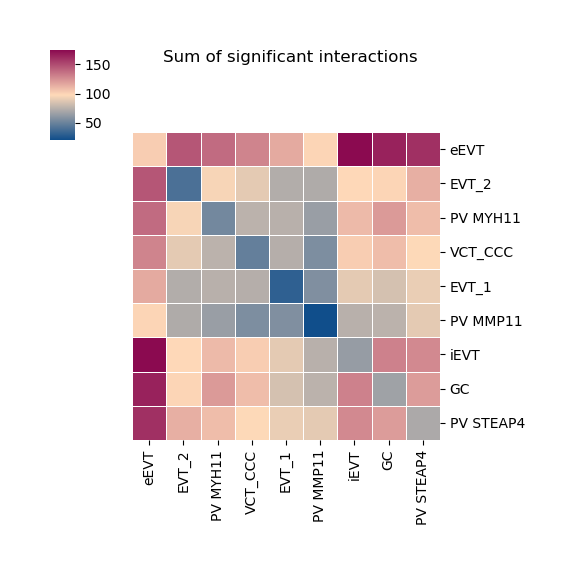

In [39]:
kpy.plot_cpdb_heatmap(
    pvals=cpdb_results['pvalues'],
    degs_analysis=False,
    figsize=(5, 5),
    title='Sum of significant interactions',
)

In [40]:
# Interactions can also be plotted grouped by pathway.

from plotnine import theme, element_text

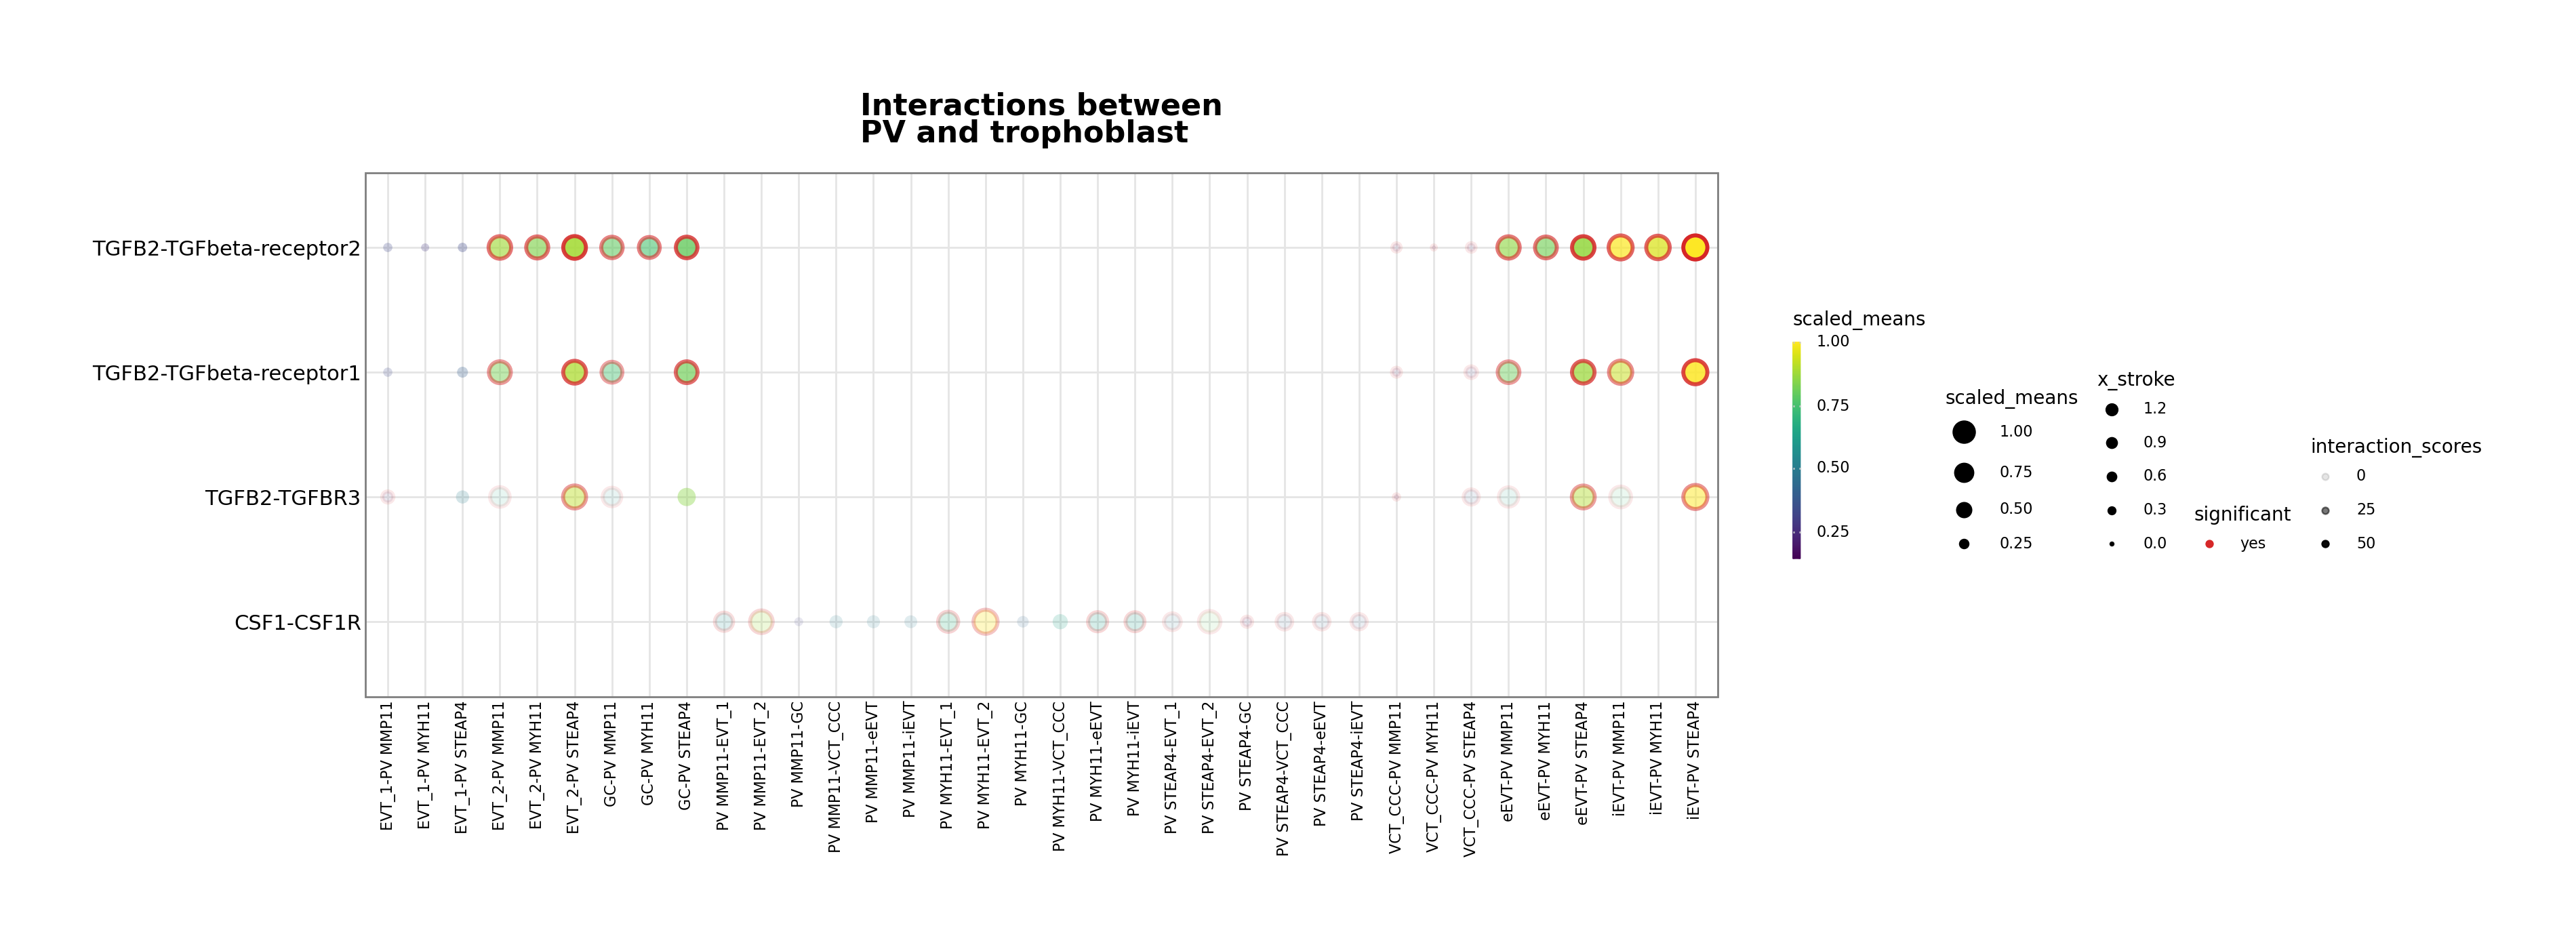

In [41]:
from plotnine import theme, element_text, element_rect

p = kpy.plot_cpdb(
    adata=adata,
    cell_type1="PV MYH11|PV STEAP4|PV MMP11",        # fixed: was "PV MMPP11"
    cell_type2="EVT_1|EVT_2|GC|iEVT|eEVT|VCT_CCC",
    means=cpdb_results['means'],
    pvals=cpdb_results['pvalues'],
    celltype_key="cell_labels",
    genes=["TGFB2", "CSF1R"],
    figsize=(18, 6),                                  # was (10, 3) -> much more breathing room
    title="Interactions between\nPV and trophoblast",
    max_size=6,                                        # was 3 -> bigger, easier-to-read dots
    highlight_size=1.2,                                 # was 0.75 -> thicker significance ring
    degs_analysis=False,
    standard_scale=True,
    interaction_scores=cpdb_results['interaction_scores'],
    scale_alpha_by_interaction_scores=True,
)

p = p + theme(
    figure_size=(18, 6),
    axis_text_x=element_text(size=8, rotation=90, ha='center'),
    axis_text_y=element_text(size=11),
    plot_title=element_text(size=16, weight='bold'),
    legend_title=element_text(size=10),
    legend_text=element_text(size=8),
    panel_background=element_rect(fill='white'),
)

p

# p.save(
#    'results/method2_noTF/pv_trophoblast_dotplot.png',
#    dpi=300, width=18, height=6, limitsize=False
# )

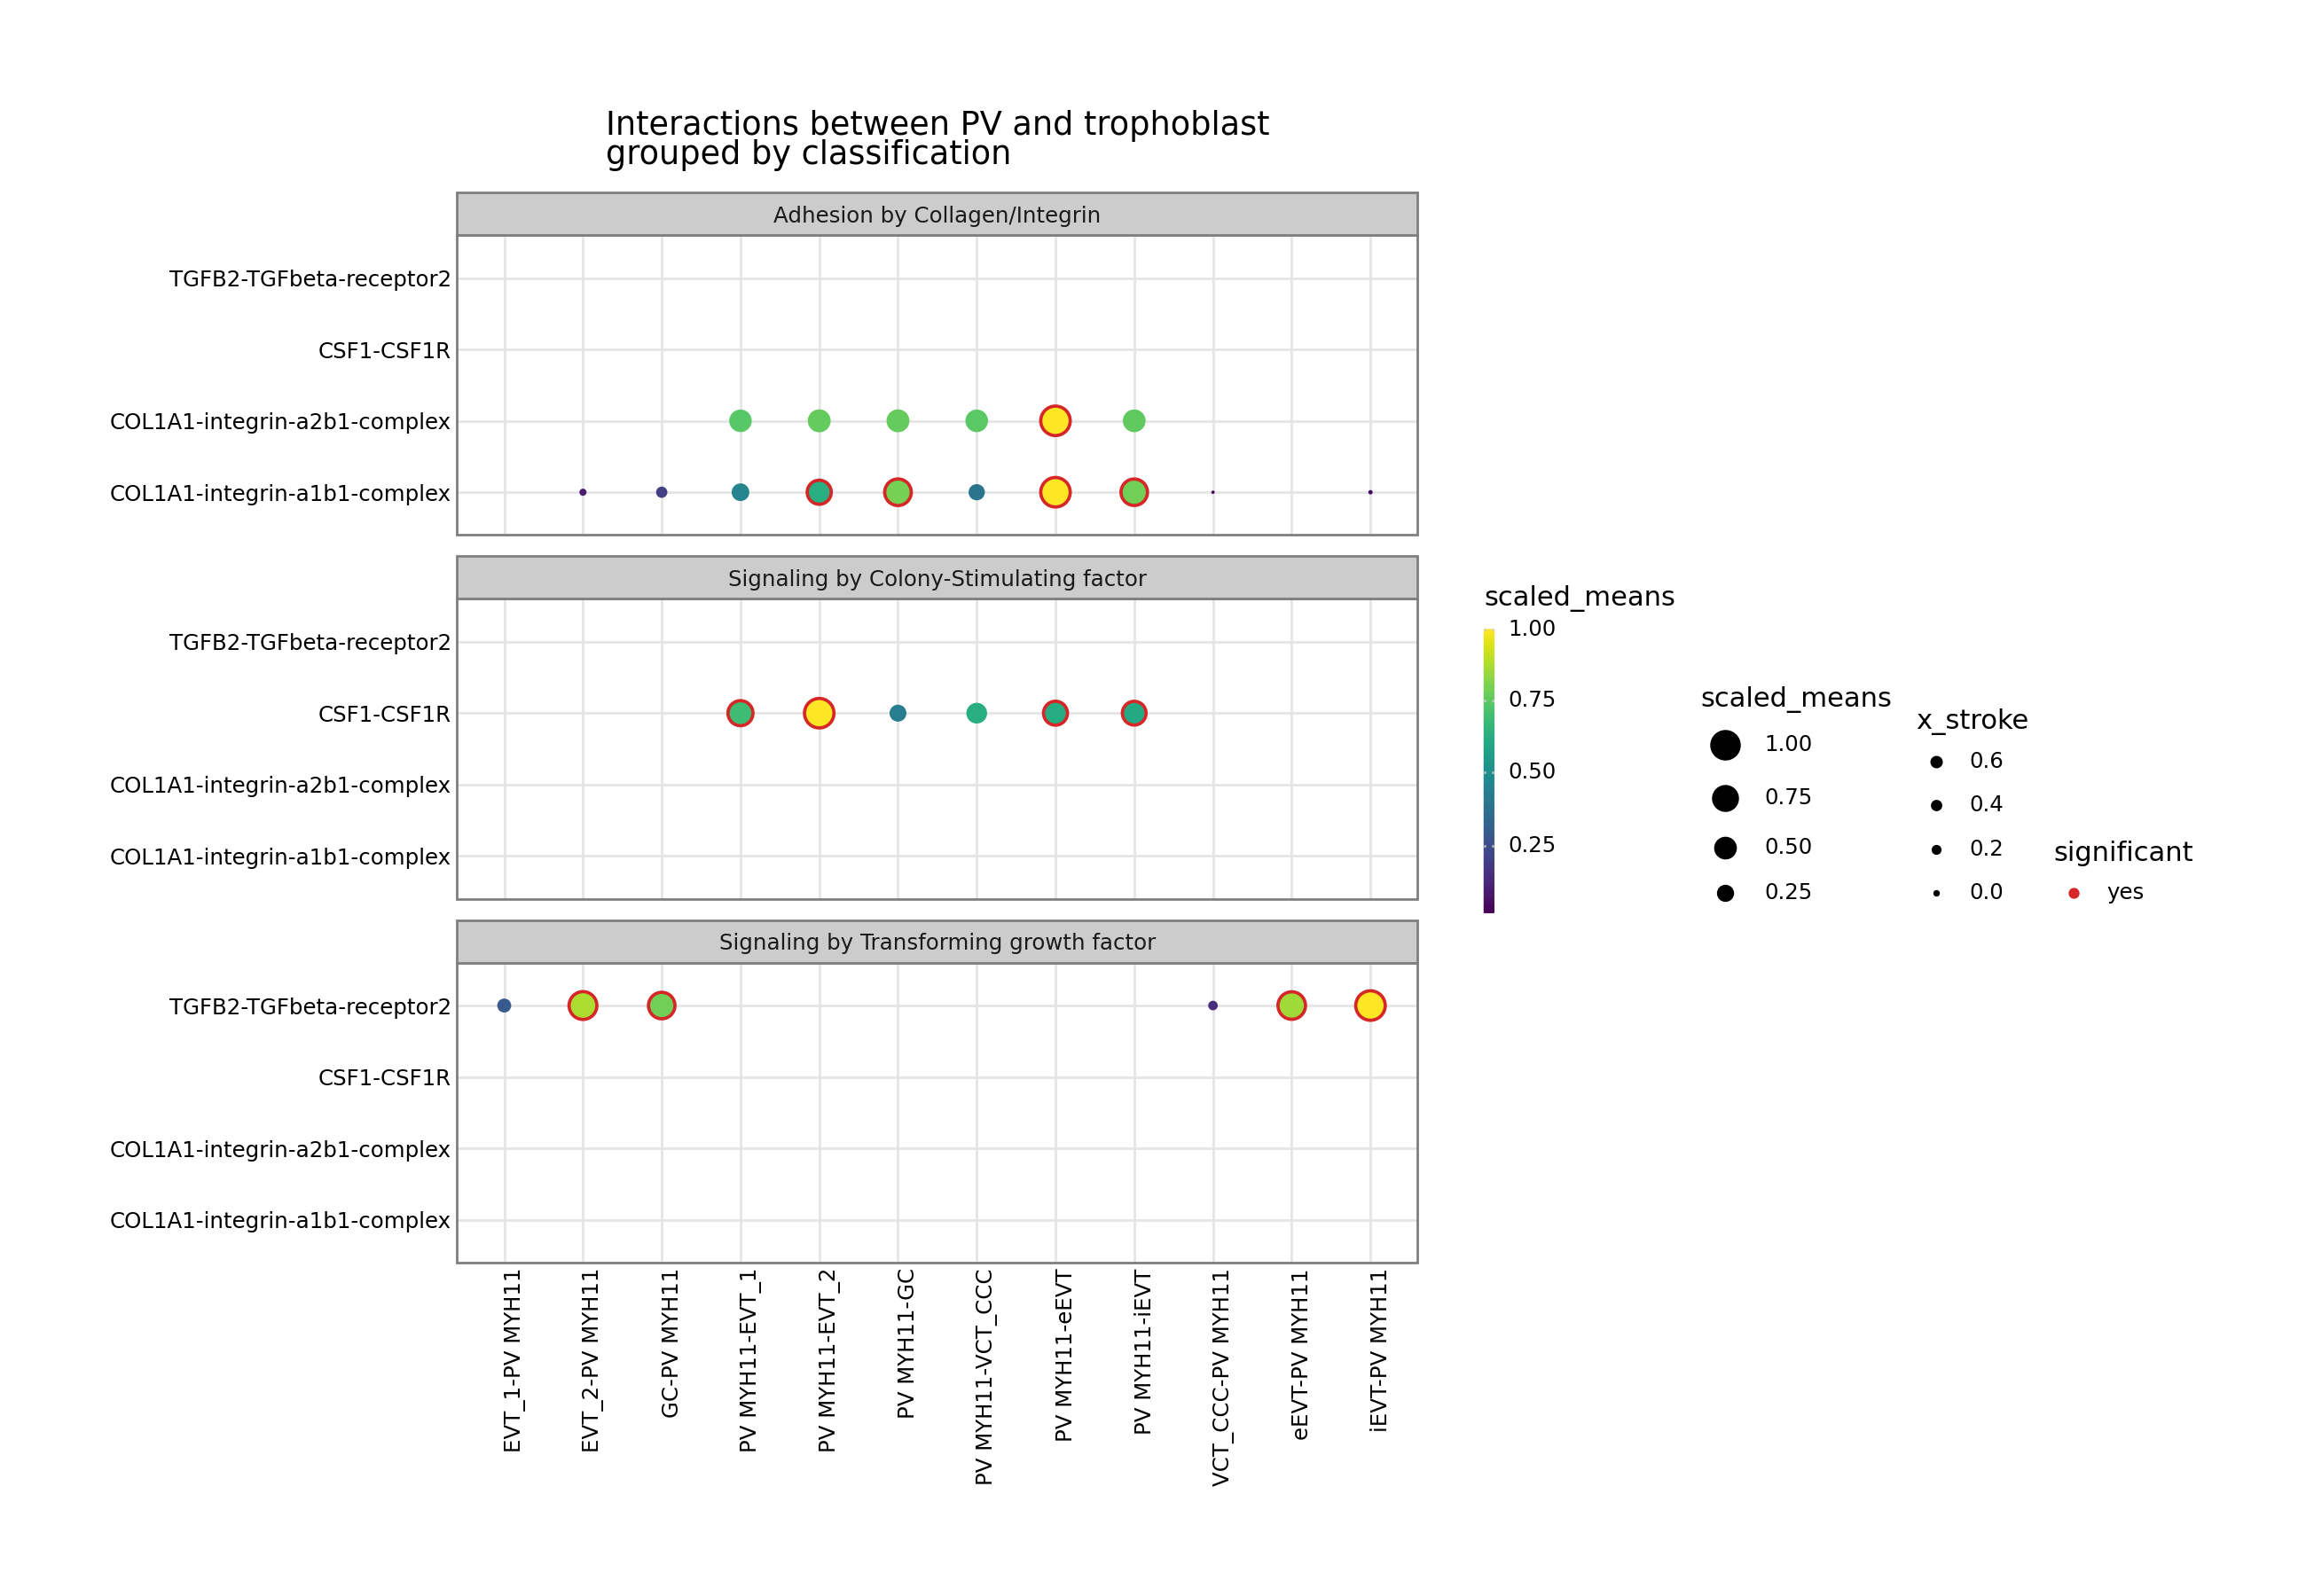

In [42]:
# dot plot faceted by classification


from plotnine import facet_wrap

p = kpy.plot_cpdb(
    adata=adata,
    cell_type1='PV MYH11',
    cell_type2='EVT_1|EVT_2|GC|iEVT|eEVT|VCT_CCC',
    means=cpdb_results['means'],
    pvals=cpdb_results['pvalues'],
    celltype_key='cell_labels',
    genes=['TGFB2', 'CSF1R', 'COL1A1'],
    figsize=(12, 8),
    title='Interactions between PV and trophoblast\ngrouped by classification',
    max_size=6,
    highlight_size=0.75,
    degs_analysis=False,
    standard_scale=True,
)
p + facet_wrap('~ classification', ncol=1)

In [43]:
# p + facet_wrap("~ classification", ncol=1) — splits the plot into one stacked panel per pathway classification, 
# so instead of one dense x-axis you get several shorter panels grouped by biological pathway